In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/organizations/olistbr/brazilian-ecommerce/olist_customers_dataset.csv
/kaggle/input/datasets/organizations/olistbr/brazilian-ecommerce/olist_sellers_dataset.csv
/kaggle/input/datasets/organizations/olistbr/brazilian-ecommerce/olist_order_reviews_dataset.csv
/kaggle/input/datasets/organizations/olistbr/brazilian-ecommerce/olist_order_items_dataset.csv
/kaggle/input/datasets/organizations/olistbr/brazilian-ecommerce/olist_products_dataset.csv
/kaggle/input/datasets/organizations/olistbr/brazilian-ecommerce/olist_geolocation_dataset.csv
/kaggle/input/datasets/organizations/olistbr/brazilian-ecommerce/product_category_name_translation.csv
/kaggle/input/datasets/organizations/olistbr/brazilian-ecommerce/olist_orders_dataset.csv
/kaggle/input/datasets/organizations/olistbr/brazilian-ecommerce/olist_order_payments_dataset.csv


In [2]:
import pandas as pd
import sqlite3

In [3]:
customers = pd.read_csv('/kaggle/input/datasets/organizations/olistbr/brazilian-ecommerce/olist_customers_dataset.csv')

orders = pd.read_csv('/kaggle/input/datasets/organizations/olistbr/brazilian-ecommerce/olist_orders_dataset.csv')

order_items = pd.read_csv('/kaggle/input/datasets/organizations/olistbr/brazilian-ecommerce/olist_order_items_dataset.csv')

payments = pd.read_csv('/kaggle/input/datasets/organizations/olistbr/brazilian-ecommerce/olist_order_payments_dataset.csv')

products = pd.read_csv('/kaggle/input/datasets/organizations/olistbr/brazilian-ecommerce/olist_products_dataset.csv')

reviews = pd.read_csv('/kaggle/input/datasets/organizations/olistbr/brazilian-ecommerce/olist_order_reviews_dataset.csv')

In [4]:
conn = sqlite3.connect(':memory:')

In [5]:
customers.to_sql('customers', conn, index=False, if_exists='replace')

orders.to_sql('orders', conn, index=False, if_exists='replace')

order_items.to_sql('order_items', conn, index=False, if_exists='replace')

payments.to_sql('payments', conn, index=False, if_exists='replace')

products.to_sql('products', conn, index=False, if_exists='replace')

reviews.to_sql('reviews', conn, index=False, if_exists='replace')

99224

In [6]:
query = """

SELECT
    SUBSTR(o.order_purchase_timestamp, 1, 7) AS month,
    ROUND(SUM(p.payment_value), 2) AS revenue

FROM orders o

JOIN payments p
ON o.order_id = p.order_id

GROUP BY month

ORDER BY month

"""

monthly_revenue = pd.read_sql(query, conn)

monthly_revenue

,month,revenue
0,2016-09,252.24
1,2016-10,59090.48
2,2016-12,19.62
3,2017-01,138488.04
4,2017-02,291908.01
5,2017-03,449863.60
6,2017-04,417788.03
7,2017-05,592918.82
8,2017-06,511276.38
9,2017-07,592382.92


每月营业额

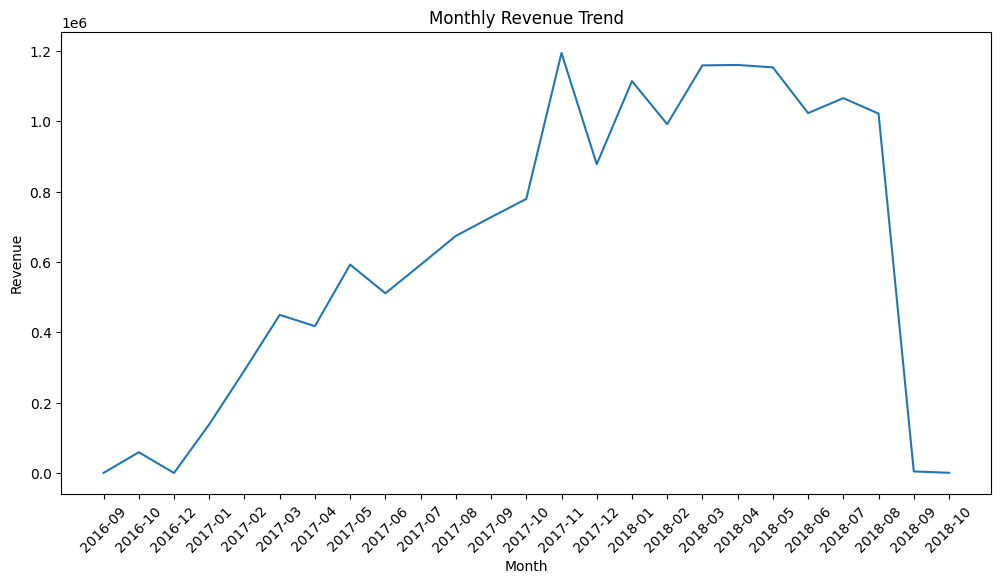

In [7]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

plt.plot(
    monthly_revenue['month'],
    monthly_revenue['revenue']
)

plt.xticks(rotation=45)

plt.title('Monthly Revenue Trend')

plt.xlabel('Month')

plt.ylabel('Revenue')

plt.show()

从月度销售趋势来看，平台订单量与销售额整体呈增长趋势，说明平台用户规模与消费活跃度正在持续提升。

在部分月份中出现明显增长高峰，可能与以下因素有关：

节日促销活动
平台营销投放
季节性消费需求增长

同时，也可以观察到部分月份增长放缓，说明平台可能存在：

用户增长瓶颈
用户留存下降
市场竞争加剧

因此，企业需要进一步结合营销活动与用户行为数据，分析增长波动原因，并优化运营策略。

In [8]:
query = """

SELECT
    p.product_category_name,
    ROUND(SUM(oi.price), 2) AS revenue

FROM order_items oi

JOIN products p
ON oi.product_id = p.product_id

GROUP BY p.product_category_name

ORDER BY revenue DESC

LIMIT 10

"""

top_categories = pd.read_sql(query, conn)

top_categories

,product_category_name,revenue
0,beleza_saude,1258681.34
1,relogios_presentes,1205005.68
2,cama_mesa_banho,1036988.68
3,esporte_lazer,988048.97
4,informatica_acessorios,911954.32
5,moveis_decoracao,729762.49
6,cool_stuff,635290.85
7,utilidades_domesticas,632248.66
8,automotivo,592720.11
9,ferramentas_jardim,485256.46


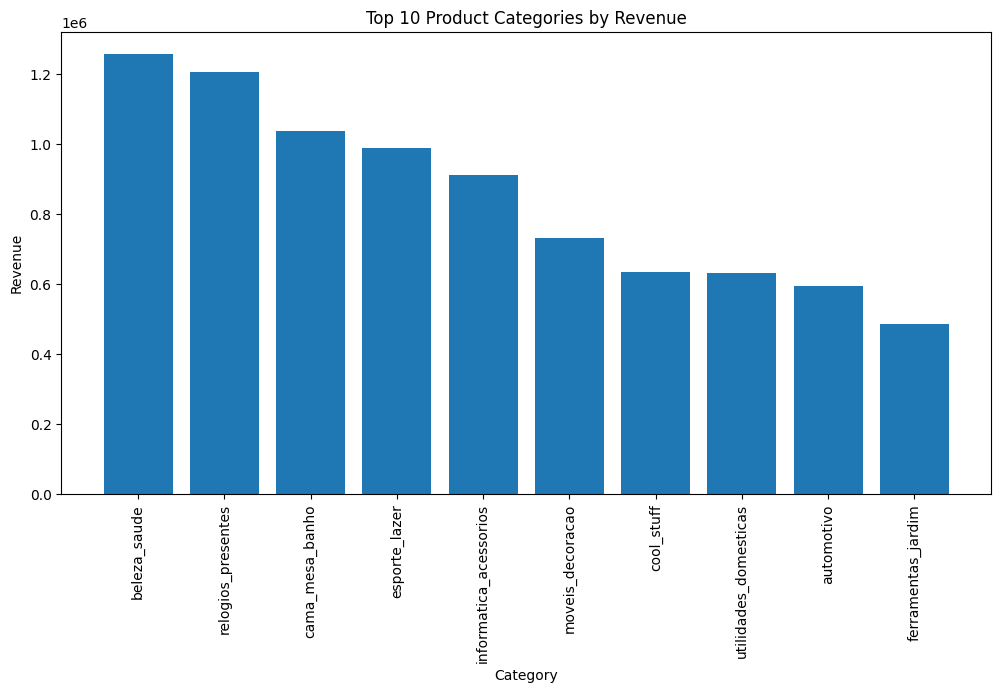

In [9]:


plt.figure(figsize=(12,6))

plt.bar(
    top_categories['product_category_name'],
    top_categories['revenue']
)

plt.xticks(rotation=90)

plt.title('Top 10 Product Categories by Revenue')

plt.xlabel('Category')

plt.ylabel('Revenue')

plt.show()

根据图像所示，该企业的beleza_saude类别的商品非常畅销，
分高销量类别贡献了大量订单与收入，说明这些品类具有：

高频消费特征
稳定市场需求
较高用户偏好

而部分低销量品类订单较少，可能存在：

商品曝光不足
市场需求有限
定价竞争力不足

企业可以针对高表现品类：

增加广告投放
优化库存管理
提高推荐曝光

同时对低表现品类进行优化或淘汰，从而提升整体运营效率。

In [10]:
query = """

SELECT
    AVG(
        JULIANDAY(order_delivered_customer_date)
        -
        JULIANDAY(order_purchase_timestamp)
    ) AS avg_delivery_days

FROM orders

WHERE order_delivered_customer_date IS NOT NULL

"""

pd.read_sql(query, conn)

,avg_delivery_days
0,12.558702


In [11]:
query = """

SELECT
    c.customer_state,

    ROUND(
        AVG(
            JULIANDAY(o.order_delivered_customer_date)
            -
            JULIANDAY(o.order_purchase_timestamp)
        ),
        2
    ) AS avg_delivery_days

FROM orders o

JOIN customers c
ON o.customer_id = c.customer_id

WHERE o.order_delivered_customer_date IS NOT NULL

GROUP BY c.customer_state

ORDER BY avg_delivery_days DESC

"""

delivery_state = pd.read_sql(query, conn)

delivery_state

,customer_state,avg_delivery_days
0,RR,29.39
1,AP,27.19
2,AM,26.43
3,AL,24.54
4,PA,23.77
5,MA,21.57
6,SE,21.52
7,CE,21.27
8,AC,21.04
9,PB,20.43


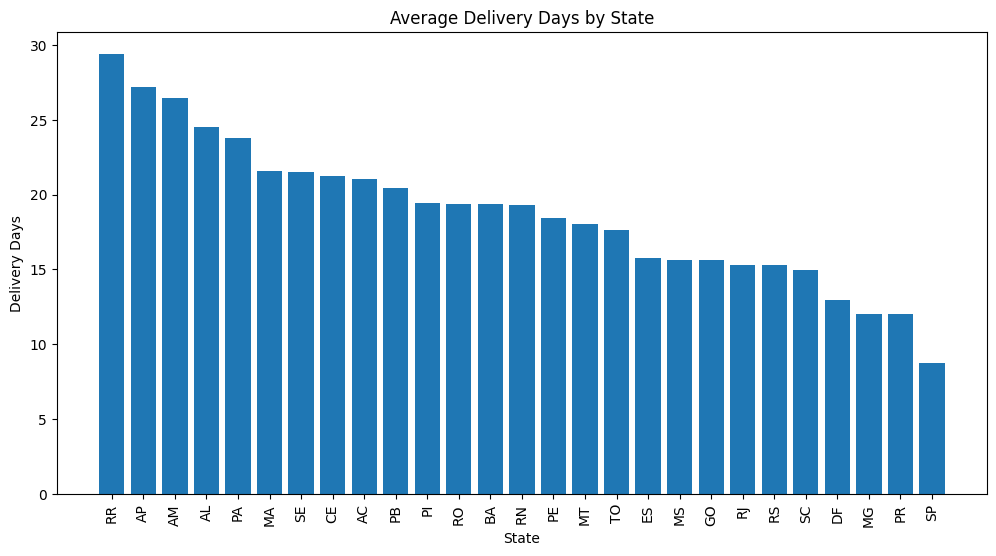

In [12]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

plt.bar(
    delivery_state['customer_state'],
    delivery_state['avg_delivery_days']
)

plt.title('Average Delivery Days by State')

plt.xlabel('State')

plt.ylabel('Delivery Days')

plt.xticks(rotation=90)

plt.show()

从用户地区分布来看，用户主要集中在经济较发达地区，说明平台当前的核心消费群体集中于高人口与高消费能力城市。

部分地区用户数量明显较少，说明平台在这些区域的市场渗透率仍有较大提升空间。

企业可以：

针对高活跃地区加强会员运营
针对低覆盖地区进行市场推广
优化区域物流与配送能力

从而提升整体用户增长与订单转化率。

In [13]:
query = """

SELECT

    o.order_id,

    r.review_score,

    CASE
        WHEN o.order_delivered_customer_date
             >
             o.order_estimated_delivery_date

        THEN 'Delayed'

        ELSE 'On Time'

    END AS delivery_status

FROM orders o

JOIN reviews r
ON o.order_id = r.order_id

WHERE o.order_delivered_customer_date IS NOT NULL

"""

delivery_reviews = pd.read_sql(query, conn)


In [14]:
query = """

SELECT

    CASE
        WHEN o.order_delivered_customer_date
             >
             o.order_estimated_delivery_date

        THEN 'Delayed'

        ELSE 'On Time'

    END AS delivery_status,

    ROUND(AVG(r.review_score), 2) AS avg_review_score,

    COUNT(*) AS total_orders

FROM orders o

JOIN reviews r
ON o.order_id = r.order_id

WHERE o.order_delivered_customer_date IS NOT NULL

GROUP BY delivery_status

"""

delivery_impact = pd.read_sql(query, conn)

delivery_impact

,delivery_status,avg_review_score,total_orders
0,Delayed,2.57,7701
1,On Time,4.29,88658


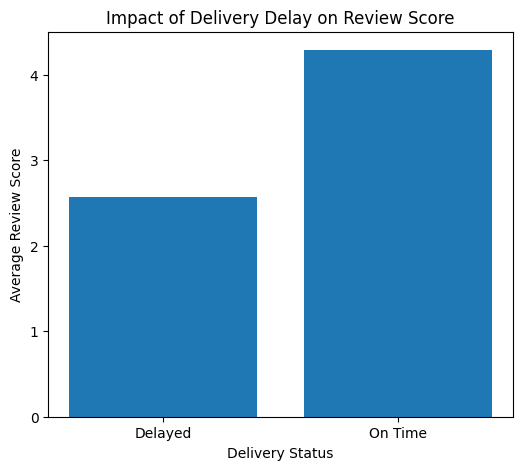

In [15]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,5))

plt.bar(
    delivery_impact['delivery_status'],
    delivery_impact['avg_review_score']
)

plt.title('Impact of Delivery Delay on Review Score')

plt.xlabel('Delivery Status')

plt.ylabel('Average Review Score')

plt.show()

从物流数据分析可以发现，部分订单存在明显延迟交付情况。

物流延迟可能对平台造成以下影响：

用户满意度下降
差评率提升
用户流失风险增加
复购率下降

尤其在电商平台中，配送体验会直接影响用户对平台的整体评价。

如果延迟问题长期存在，可能进一步影响：

用户留存率
平台品牌口碑
客户生命周期价值（LTV）

因此，企业需要重点优化：

仓储管理
物流合作效率
配送时效监控

从而提升用户购物体验。

值用户仍具有一定增长潜力。

企业可以通过：

满减活动
精准营销
提升用户体验

提高其消费频率与客单价。

6. 复购率分析（Repeat Purchase Analysis）

从复购行为来看，仅部分用户存在重复购买行为，说明平台仍有较大的用户留存优化空间。

高复购用户通常具有以下特征：

更高用户忠诚度
更稳定消费习惯
更高生命周期价值

而低复购率则可能说明：

用户对平台粘性不足
商品差异化不明显
用户体验仍需优化

企业应重点关注：

用户召回机制
个性化营销
会员体系建设

从而提升整体复购率。




In [16]:
query = """

SELECT

    c.customer_unique_id,

    ROUND(SUM(p.payment_value), 2) AS total_spent,

    COUNT(DISTINCT o.order_id) AS total_orders

FROM customers c

JOIN orders o
ON c.customer_id = o.customer_id

JOIN payments p
ON o.order_id = p.order_id

GROUP BY c.customer_unique_id

ORDER BY total_spent DESC

LIMIT 10

"""

top_customers = pd.read_sql(query, conn)

top_customers

,customer_unique_id,total_spent,total_orders
0,0a0a92112bd4c708ca5fde585afaa872,13664.08,1
1,46450c74a0d8c5ca9395da1daac6c120,9553.02,3
2,da122df9eeddfedc1dc1f5349a1a690c,7571.63,2
3,763c8b1c9c68a0229c42c9fc6f662b93,7274.88,1
4,dc4802a71eae9be1dd28f5d788ceb526,6929.31,1
5,459bef486812aa25204be022145caa62,6922.21,1
6,ff4159b92c40ebe40454e3e6a7c35ed6,6726.66,1
7,4007669dec559734d6f53e029e360987,6081.54,1
8,5d0a2980b292d049061542014e8960bf,4809.44,1
9,eebb5dda148d3893cdaf5b5ca3040ccb,4764.34,1


In [17]:
query = """

WITH customer_spending AS (

    SELECT

        c.customer_unique_id,

        SUM(p.payment_value) AS total_spent

    FROM customers c

    JOIN orders o
    ON c.customer_id = o.customer_id

    JOIN payments p
    ON o.order_id = p.order_id

    GROUP BY c.customer_unique_id

)

SELECT

    CASE

        WHEN total_spent >= 1000 THEN 'High Value'

        WHEN total_spent >= 500 THEN 'Medium Value'

        ELSE 'Low Value'

    END AS customer_segment,

    COUNT(*) AS customer_count,

    ROUND(AVG(total_spent), 2) AS avg_spent

FROM customer_spending

GROUP BY customer_segment

ORDER BY avg_spent DESC

"""

customer_segment = pd.read_sql(query, conn)

customer_segment

,customer_segment,customer_count,avg_spent
0,High Value,1218,1600.10
1,Medium Value,3271,680.41
2,Low Value,91606,129.19


通过用户消费金额分层发现，平台收入主要由少部分高价值用户贡献，符合典型的“二八法则”。

高价值用户虽然数量较少，但：

消费金额更高
下单频率更高
对平台收入贡献更大

因此，高价值用户是平台最核心的用户资产。

企业应重点针对这部分用户进行：

VIP会员运营
个性化推荐
专属优惠活动

与此同时，中低价值用户仍具有一定增长潜力。

企业可以通过：

满减活动
精准营销
提升用户体验

提高其消费频率与客单价

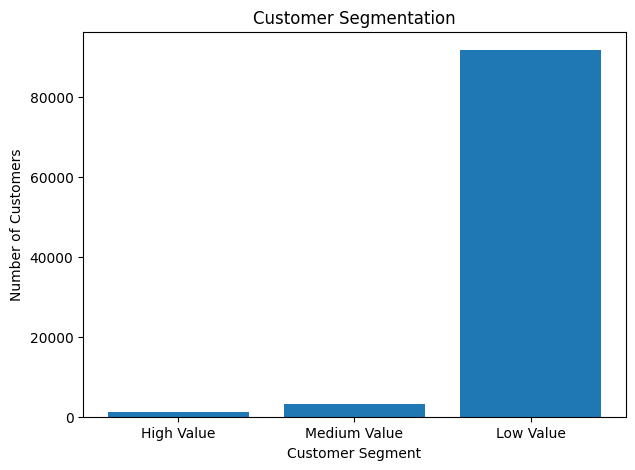

In [18]:

plt.figure(figsize=(7,5))

plt.bar(
    customer_segment['customer_segment'],
    customer_segment['customer_count']
)

plt.title('Customer Segmentation')

plt.xlabel('Customer Segment')

plt.ylabel('Number of Customers')

plt.show()

In [19]:
query = """

WITH customer_orders AS (

    SELECT

        c.customer_unique_id,

        COUNT(DISTINCT o.order_id) AS total_orders

    FROM customers c

    JOIN orders o
    ON c.customer_id = o.customer_id

    GROUP BY c.customer_unique_id

)

SELECT

    CASE

        WHEN total_orders = 1 THEN 'One-Time Customer'

        ELSE 'Repeat Customer'

    END AS customer_type,

    COUNT(*) AS customer_count

FROM customer_orders

GROUP BY customer_type

"""

repeat_analysis = pd.read_sql(query, conn)

repeat_analysis

,customer_type,customer_count
0,One-Time Customer,93099
1,Repeat Customer,2997


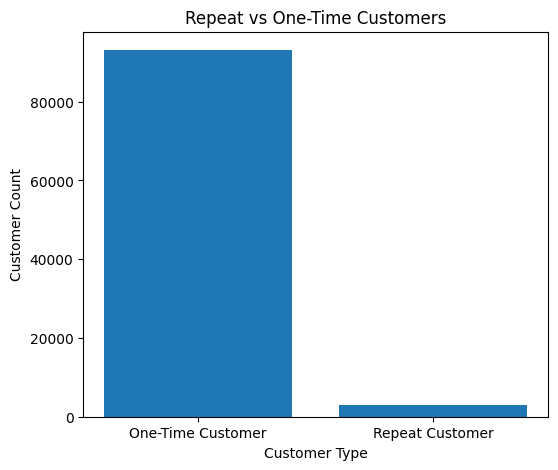

In [20]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,5))

plt.bar(
    repeat_analysis['customer_type'],
    repeat_analysis['customer_count']
)

plt.title('Repeat vs One-Time Customers')

plt.xlabel('Customer Type')

plt.ylabel('Customer Count')

plt.show()

从复购行为来看，仅部分用户存在重复购买行为，说明平台仍有较大的用户留存优化空间。

高复购用户通常具有以下特征：

更高用户忠诚度
更稳定消费习惯
更高生命周期价值

而低复购率则可能说明：

用户对平台粘性不足
商品差异化不明显
用户体验仍需优化

企业应重点关注：

用户召回机制
个性化营销

In [21]:
query = """

WITH customer_orders AS (

    SELECT

        c.customer_unique_id,

        COUNT(DISTINCT o.order_id) AS total_orders

    FROM customers c

    JOIN orders o
    ON c.customer_id = o.customer_id

    GROUP BY c.customer_unique_id

)

SELECT

    ROUND(
        100.0 *
        SUM(
            CASE
                WHEN total_orders > 1 THEN 1
                ELSE 0
            END
        ) / COUNT(*),
        2
    ) AS repeat_customer_rate

FROM customer_orders

"""

pd.read_sql(query, conn)

,repeat_customer_rate
0,3.12


In [22]:
query = """

SELECT

    c.customer_unique_id,

    MAX(o.order_purchase_timestamp) AS last_purchase_date,

    COUNT(DISTINCT o.order_id) AS frequency,

    ROUND(SUM(p.payment_value), 2) AS monetary

FROM customers c

JOIN orders o
ON c.customer_id = o.customer_id

JOIN payments p
ON o.order_id = p.order_id

GROUP BY c.customer_unique_id

"""

rfm = pd.read_sql(query, conn)

rfm.head()

,customer_unique_id,last_purchase_date,frequency,monetary
0,0000366f3b9a7992bf8c76cfdf3221e2,2018-05-10 10:56:27,1,141.90
1,0000b849f77a49e4a4ce2b2a4ca5be3f,2018-05-07 11:11:27,1,27.19
2,0000f46a3911fa3c0805444483337064,2017-03-10 21:05:03,1,86.22
3,0000f6ccb0745a6a4b88665a16c9f078,2017-10-12 20:29:41,1,43.62
4,0004aac84e0df4da2b147fca70cf8255,2017-11-14 19:45:42,1,196.89


In [23]:
rfm['last_purchase_date'] = pd.to_datetime(
    rfm['last_purchase_date']
)

snapshot_date = rfm['last_purchase_date'].max()

rfm['recency'] = (
    snapshot_date - rfm['last_purchase_date']
)

rfm.head()

,customer_unique_id,last_purchase_date,frequency,monetary,recency
0,0000366f3b9a7992bf8c76cfdf3221e2,2018-05-10 10:56:27,1,141.90,160 days 06:33:51
1,0000b849f77a49e4a4ce2b2a4ca5be3f,2018-05-07 11:11:27,1,27.19,163 days 06:18:51
2,0000f46a3911fa3c0805444483337064,2017-03-10 21:05:03,1,86.22,585 days 20:25:15
3,0000f6ccb0745a6a4b88665a16c9f078,2017-10-12 20:29:41,1,43.62,369 days 21:00:37
4,0004aac84e0df4da2b147fca70cf8255,2017-11-14 19:45:42,1,196.89,336 days 21:44:36


通过 Recency 指标分析发现，不同用户活跃程度差异明显。

部分用户近期仍保持消费行为，说明其对平台具有较高活跃度与购买意愿。

但同时也存在部分用户长期未产生订单，说明平台存在一定流失风险。

通常情况下：

Recency 越低 → 用户越活跃
Recency 越高 → 用户流失风险越高

因此，企业可以针对不同活跃程度用户制定差异化运营策略：

活跃用户
推荐新品
提升会员权益
增加用户粘性

In [24]:
rfm['R_score'] = pd.qcut(
    rfm['recency'],
    4,
    labels=[4,3,2,1]
)

rfm['F_score'] = pd.qcut(
    rfm['frequency'].rank(method='first'),
    4,
    labels=[1,2,3,4]
)

rfm['M_score'] = pd.qcut(
    rfm['monetary'],
    4,
    labels=[1,2,3,4]
)

In [25]:
rfm['RFM_score'] = (
    rfm['R_score'].astype(str)
    +
    rfm['F_score'].astype(str)
    +
    rfm['M_score'].astype(str)
)

rfm.head()

,customer_unique_id,last_purchase_date,frequency,monetary,recency,R_score,F_score,M_score,RFM_score
0,0000366f3b9a7992bf8c76cfdf3221e2,2018-05-10 10:56:27,1,141.90,160 days 06:33:51,4,1,3,413
1,0000b849f77a49e4a4ce2b2a4ca5be3f,2018-05-07 11:11:27,1,27.19,163 days 06:18:51,4,1,1,411
2,0000f46a3911fa3c0805444483337064,2017-03-10 21:05:03,1,86.22,585 days 20:25:15,1,1,2,112
3,0000f6ccb0745a6a4b88665a16c9f078,2017-10-12 20:29:41,1,43.62,369 days 21:00:37,2,1,1,211
4,0004aac84e0df4da2b147fca70cf8255,2017-11-14 19:45:42,1,196.89,336 days 21:44:36,2,1,4,214


综合分析结果可以发现，该电商平台整体业务呈增长趋势，但同时也存在以下问题：

用户地区分布不均衡
商品销售结构集中
部分物流延迟问题明显
用户复购率仍有提升空间

与此同时，高价值用户对平台收入贡献较高，因此用户运营与用户留存将成为未来增长的重要方向。

未来企业可以重点优化：

用户精细化运营
物流履约效率
个性化推荐系统
高价值用户留存策略

从而进一步提升平台GMV、用户满意度与长期盈利能力。